# Project: Investigate a Dataset - Shopping Trends

## Table of Contents
- Introduction

- Data Wrangling

- Data Cleaning

- Exploratory Data Analysis

- Conclusions


-----


## Introduction

### Dataset Description

This dataset contains detailed records of **3,900** shopping transactions, reflecting customer behavior and purchasing patterns. It offers insights into how different factors influence buying decisions and helps identify trends that can support business and marketing strategies.



### Column Descriptions

- **Customer_ID**: A unique identifier assigned to each customer.

- **Age**: Age of the customer.

- **Gender**: Gender of the customer (Male, Female).

- **Item_Purchased**: Name of the specific item bought by the customer.

- **Category**: General category of the purchased item (e.g., Clothing, Footwear).

- **Purchase_Amount_USD**: Total amount spent by the customer on the purchase, in US Dollars.

- **Location**: The US state where the customer resides.

- **Size**: Size of the purchased item (e.g., S, M, L).

- **Color**: Color of the purchased item.

- **Season**: The season during which the item was purchased (e.g., Winter, Spring).

- **Review_Rating**: Customer’s rating of the product on a scale of 1 to 5.

- **Subscription_Status**: Indicates whether the customer is subscribed to a service or newsletter (Yes/No).

- **Payment_Method**: Method used by the customer to make the payment (e.g., Credit Card, PayPal, Cash).

- **Shipping_Type**: Type of shipping selected by the customer (e.g., Express, Free Shipping, Next Day Air).

- **Discount_Applied**: Indicates if a discount was applied to the purchase (Yes/No).

- **Promo_Code_Used**: Indicates whether the customer used a promotional code (Yes/No).

- **Previous_Purchases**: The number of purchases the customer has made prior to this transaction.

- **Preferred_Payment_Method**: The payment method the customer typically prefers.

- **Frequency_of_Purchases**: How often the customer makes purchases (e.g., Weekly, Fortnightly).


### Questions for Analysis:

1. Who buys more — males or females?

2. What’s the most sold size in clothing/footwear to stock more offers?

3. What products get the lowest ratings and need improvement?

4. What are the most and least buying locations?

5. How much do people who get a discount buy compared to those who don’t?

6. What are the most sold categories to stop discounting? And what to promote more?

8. people buys much (Outliers) what is the correlation between them, what they buy.

---

## Environment set-up


In [1]:
# importing Libraries.
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import pyodbc 

import warnings
warnings.filterwarnings("ignore")

---

## Data Wrangling
In this section, we would load our desired data from a flat csv file using pandas to further explore our data.

In [2]:
# Connect to Database
conn_str = (
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=gebaly;'
    'DATABASE=Instant;'
    'Trusted_Connection=yes;'
)

conn = pyodbc.connect(conn_str)

In [ ]:
    # loading data and showing its first 5 lines
query = "SELECT * FROM dbo.shopping_trends"
df = pd.read_sql(query, conn)

df.head()

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


---

## Data Cleaning
In this section, we would dive deeper into exploring our dataset and perform cleaning operations like (dropping columns, handling NaNs, converting data types). All of which would help us reach a more accurate result in answering our investigating questions

In [4]:
# printing columns info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item_Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase_Amount_USD       3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review_Rating             3900 non-null   float64
 11  Subscription_Status       3900 non-null   object 
 12  Payment_Method            3900 non-null   object 
 13  Shipping_Type             3900 non-null   object 
 14  Discount

In [5]:
# number of unique values for each column
df.nunique()

Customer_ID                 3900
Age                           53
Gender                         2
Item_Purchased                25
Category                       4
Purchase_Amount_USD           81
Location                      50
Size                           4
Color                         25
Season                         4
Review_Rating                 26
Subscription_Status            2
Payment_Method                 6
Shipping_Type                  6
Discount_Applied               2
Promo_Code_Used                2
Previous_Purchases            50
Preferred_Payment_Method       6
Frequency_of_Purchases         7
dtype: int64

In [6]:
# closer look at Review_Rating column
df["Review_Rating"].describe()

count    3900.000000
mean        3.749949
std         0.716223
min         2.500000
25%         3.100000
50%         3.700000
75%         4.400000
max         5.000000
Name: Review_Rating, dtype: float64

In [7]:
# checking duplicated values 
df.duplicated().sum()

np.int64(0)

In [8]:
# making sure there are no null values
df.isnull().sum()

Customer_ID                 0
Age                         0
Gender                      0
Item_Purchased              0
Category                    0
Purchase_Amount_USD         0
Location                    0
Size                        0
Color                       0
Season                      0
Review_Rating               0
Subscription_Status         0
Payment_Method              0
Shipping_Type               0
Discount_Applied            0
Promo_Code_Used             0
Previous_Purchases          0
Preferred_Payment_Method    0
Frequency_of_Purchases      0
dtype: int64

In [9]:
# quick summary of the numeric columns
df.describe()

,Customer_ID,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


### As we can see from the above output:

1. Our dataset consists of a total of 3900 rows and 19 columns.

2. We have no duplicated row.

3. Some columns wont be useful in answering our questions using analysis.

4. We have no null values in our data.

5. Review_Rating better be presented as a catecorical variable that groubs multible ratings values.

---

#### **Check for data frame columns**

In [10]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Payment_Method',
       'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used',
       'Previous_Purchases', 'Preferred_Payment_Method',
       'Frequency_of_Purchases'],
      dtype='object')

After going through all the columns, i decided that columns: Customer_ID Color Season Subscription_Status Shipping_Type Promo_Code_Used Preferred_Payment_Method  will not be very usefull for my analysis, so i will drop them and continue with our analysis

In [11]:
# Preferred_Payment_Method
df.drop(["Customer_ID","Color","Season","Subscription_Status", "Shipping_Type", "Promo_Code_Used", "Preferred_Payment_Method"], axis = 1, inplace = True)

In [12]:
df.shape

(3900, 12)

Now we only have 9 columns to start preprocessing on



---

##### **Catigorizing Review_Rating column**

For usability and functionality sake, we would convert this column using a function.



In [13]:
df["Review_Rating"].describe()

count    3900.000000
mean        3.749949
std         0.716223
min         2.500000
25%         3.100000
50%         3.700000
75%         4.400000
max         5.000000
Name: Review_Rating, dtype: float64

In [14]:
[df["Review_Rating"].describe()['min'],
 df["Review_Rating"].describe()['25%'],
 df["Review_Rating"].describe()['50%'],
 df["Review_Rating"].describe()['75%'],
 df["Review_Rating"].describe()['max']]

[np.float64(2.5),
 np.float64(3.0999999046325684),
 np.float64(3.700000047683716),
 np.float64(4.400000095367432),
 np.float64(5.0)]

In [8]:
def catigorize_col(df, col, labels, new_col_name):
    """
    catigorizes a certain column based on its quartiles
   
    Args:
        (df)     df   - dataframe we are proccesing
        (col)    str  - to be catigorized column's name 
        (labels) list - list of labels from min to max
        (new_col_name) str - to add new column with different name
    
    Returns:
        (df)     df   - dataframe with the categorized col
    """

    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]

    df[new_col_name] = pd.cut(df[col], edges, labels = labels, duplicates='drop')
    return df


We would cut the Review_Rating values and make 3 categories: Bad Good Very_Good to describe it more using catigorize_col() function provided above.

In [9]:
labels = ['Bad', 'Good', "Very_Good"]
catigorize_col(df, "Review_Rating", labels, "Review_Rating_Categories")

df["Review_Rating_Categories"].unique()

['Bad', 'Good', 'Very_Good', NaN]
Categories (3, object): ['Bad' < 'Good' < 'Very_Good']

In [17]:
df["Review_Rating_Categories"].value_counts()

Review_Rating_Categories
Good         2057
Bad           938
Very_Good     839
Name: count, dtype: int64

In [18]:
df["Review_Rating_Categories"].isnull().sum()

np.int64(66)

We endded up with some NaNs, so wo would drop them.

In [10]:
df.dropna(inplace = True)

In [20]:
df.head(10)

,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Review_Rating,Payment_Method,Discount_Applied,Previous_Purchases,Frequency_of_Purchases,Review_Rating_Categories
0,55,Male,Blouse,Clothing,53,Kentucky,L,3.1,Credit Card,Yes,14,Fortnightly,Bad
1,19,Male,Sweater,Clothing,64,Maine,L,3.1,Bank Transfer,Yes,2,Fortnightly,Bad
2,50,Male,Jeans,Clothing,73,Massachusetts,S,3.1,Cash,Yes,23,Weekly,Bad
3,21,Male,Sandals,Footwear,90,Rhode Island,M,3.5,PayPal,Yes,49,Weekly,Good
4,45,Male,Blouse,Clothing,49,Oregon,M,2.7,Cash,Yes,31,Annually,Bad
5,46,Male,Sneakers,Footwear,20,Wyoming,M,2.9,Venmo,Yes,14,Weekly,Bad
6,63,Male,Shirt,Clothing,85,Montana,M,3.2,Debit Card,Yes,49,Quarterly,Good
7,27,Male,Shorts,Clothing,34,Louisiana,L,3.2,Debit Card,Yes,19,Weekly,Good
8,26,Male,Coat,Outerwear,97,West Virginia,L,2.6,Venmo,Yes,8,Annually,Bad
9,57,Male,Handbag,Accessories,31,Missouri,M,4.8,PayPal,Yes,4,Quarterly,Very_Good


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3834 entries, 0 to 3899
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       3834 non-null   int64   
 1   Gender                    3834 non-null   object  
 2   Item_Purchased            3834 non-null   object  
 3   Category                  3834 non-null   object  
 4   Purchase_Amount_USD       3834 non-null   int64   
 5   Location                  3834 non-null   object  
 6   Size                      3834 non-null   object  
 7   Review_Rating             3834 non-null   float64 
 8   Payment_Method            3834 non-null   object  
 9   Discount_Applied          3834 non-null   object  
 10  Previous_Purchases        3834 non-null   int64   
 11  Frequency_of_Purchases    3834 non-null   object  
 12  Review_Rating_Categories  3834 non-null   category
dtypes: category(1), float64(1), int64(3), object(8)
memor

Now that we finished our data cleaning, our dataset consists of 3834 records with 13 columns, it has no duplicates nor null values, and the data types are consistant with suitable categorical variable to address our questions. We are ready to move to the next step!

---

## Exploratory Data Analysis - EDA

In this section, we would use describtive statistics and visuals to address the following questions regarding our dataset

#### **Q1: Who buys more — males or females?**


In [22]:
df["Gender"].value_counts()

Gender
Male      2608
Female    1226
Name: count, dtype: int64

In [23]:
df.groupby("Gender")["Previous_Purchases"].sum()

Gender
Female    30223
Male      67011
Name: Previous_Purchases, dtype: int64

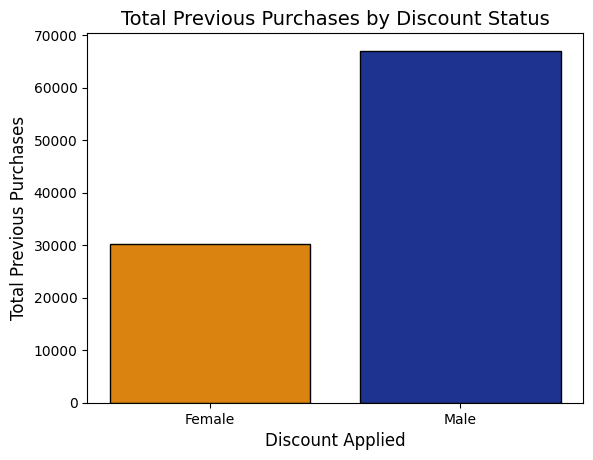

In [24]:
x_labels = ["Female", "Male"]
y_values = df.groupby("Gender")["Previous_Purchases"].sum()

plt.bar(x_labels, y_values, color=["#DA8311","#1E338F" ], edgecolor='black')
plt.title("Total Previous Purchases by Discount Status", fontsize=14)
plt.xlabel("Discount Applied", fontsize=12)
plt.ylabel("Total Previous Purchases", fontsize=12)
plt.xticks(rotation=0)
plt.show()


As we can see, the majority of buyers are males (67,011), so we can offer consumption products such as men's perfume, protein bars, body spray, and so on.

------

#### **Q2: What’s the most sold size in clothing/footwear/Outerwear to stock more?**

In [25]:
ct=pd.crosstab(df["Category"],df["Size"])[1:]
ct

Size,L,M,S,XL
Category,,,,
Clothing,476,763,282,189
Footwear,170,261,91,67
Outerwear,90,144,56,27


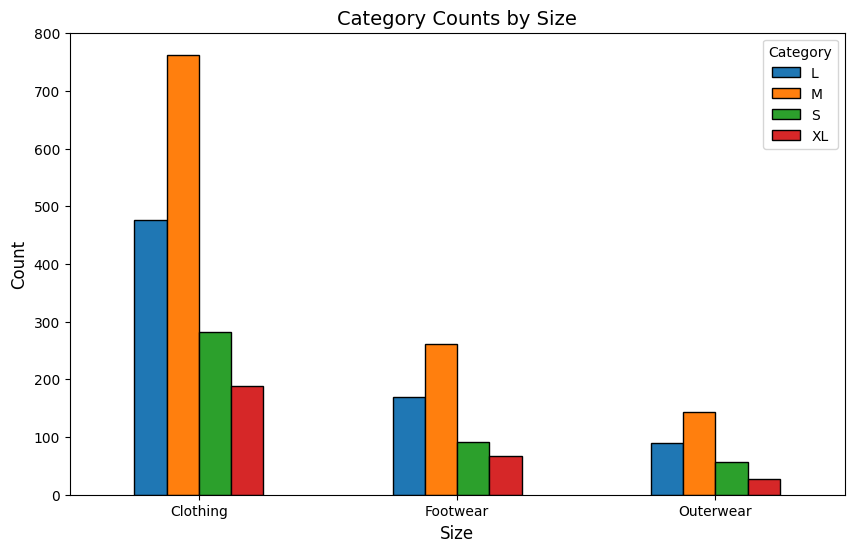

In [26]:
ct.plot(kind='bar', figsize=(10,6), edgecolor='black')

# Enhancements
plt.title("Category Counts by Size", fontsize=14)
plt.xlabel("Size", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.show()

In [27]:
ct.idxmax(axis=1)  # most common category Size

Category
Clothing     M
Footwear     M
Outerwear    M
dtype: object

From the data, it's clear that the medium size has the highest number of sales.
Therefore, we should increase the stock of medium-sized items to meet customer demand.

----

#### **Q3: What products get the lowest ratings and need improvement?**

In [28]:
df[df["Review_Rating_Categories"]=="Bad"]["Item_Purchased"].value_counts().head(10)

Item_Purchased
Blouse        53
Shirt         52
Shorts        44
Pants         43
Hoodie        43
Jewelry       42
Coat          41
Sweater       40
Scarf         40
Sunglasses    40
Name: count, dtype: int64

These are the top 10 items with the worst ratings, so we should investigate what caused these low ratings and work on improving the products.

---

#### **Q4 What are the most and least Revenue of locations?**

In [29]:
most_rev_location = df.groupby("Location")["Purchase_Amount_USD"].sum().sort_values(ascending=False)[:3] # Most 3 Revenue Locations
most_rev_location

Location
Montana     5660
Illinois    5617
Nevada      5514
Name: Purchase_Amount_USD, dtype: int64

In [30]:
least_rev_location = df.groupby("Location")["Purchase_Amount_USD"].sum().sort_values(ascending=True)[:3] # Least 3 Revenue Locations
least_rev_location

Location
Kansas     3348
Florida    3671
Hawaii     3711
Name: Purchase_Amount_USD, dtype: int64

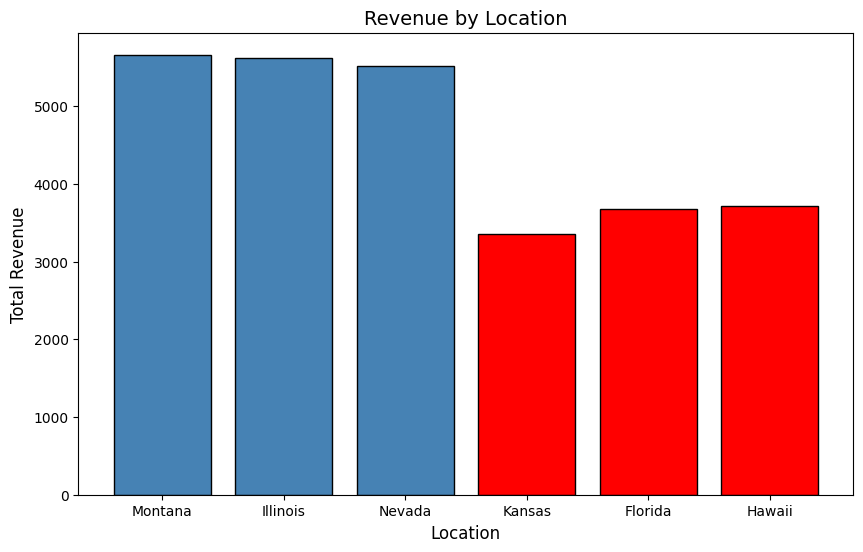

In [31]:
combined = pd.concat([most_rev_location, least_rev_location])
colors = ['red' if val in combined.nsmallest(3).values else 'steelblue' for val in combined]

plt.figure(figsize=(10,6))
plt.bar(combined.index, combined.values, color=colors, edgecolor='black')

plt.title("Revenue by Location", fontsize=14)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=0)
plt.show()

Here we can see the three locations with the lowest revenue. We should study the market in these areas to identify the issues and work on improving performance.

#### **Q5: How much do people who get a discount buy compared to those who don’t?**


In [32]:
df.groupby('Discount_Applied').Previous_Purchases.sum()

Discount_Applied
No     54834
Yes    42400
Name: Previous_Purchases, dtype: int64

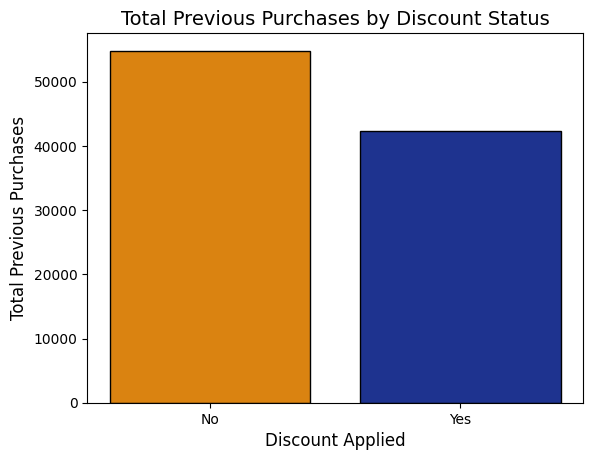

In [33]:
x_labels = ["No", "Yes"]
y_values = df.groupby('Discount_Applied')['Previous_Purchases'].sum()

plt.bar(x_labels, y_values, color=["#DA8311","#1E338F" ], edgecolor='black')

plt.title("Total Previous Purchases by Discount Status", fontsize=14)
plt.xlabel("Discount Applied", fontsize=12)
plt.ylabel("Total Previous Purchases", fontsize=12)

plt.show()


We can see that the number of customer visits to shop and get discounts is not small (42400), so we can offer more discounts to increase the consistency of customer visits.

---

#### **Q6: What are the most sold categories to promote more?**

In [34]:
df.Category.value_counts()

Category
Clothing       1710
Accessories    1218
Footwear        589
Outerwear       317
Name: count, dtype: int64

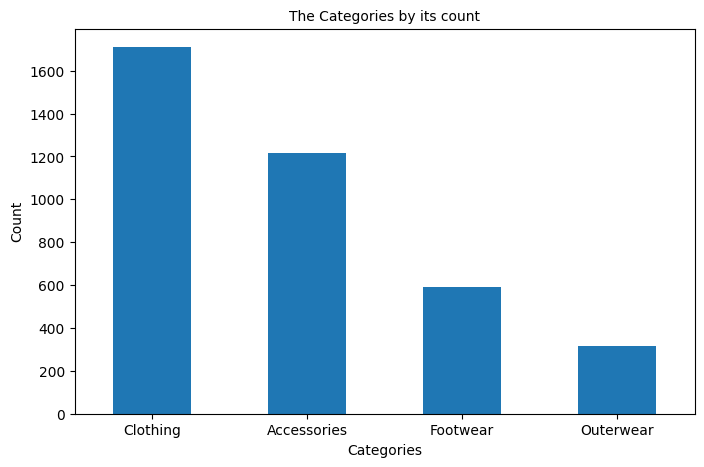

In [35]:
plt.figure(figsize=(8,5))
df['Category'].value_counts().plot(kind="bar")
plt.title("The Categories by its count", fontsize=(10))
plt.xlabel("Categories", fontsize=10)
plt.ylabel("Count",fontsize=10)
plt.xticks(rotation=0)
plt.show()

We see here that the most sold category is clothing and the least sold category is outerwear, so we can add a discount on these categories to improve sales.

----

In [36]:
pd.crosstab(df["Category"],df["Frequency_of_Purchases"])

Frequency_of_Purchases,Annually,Bi-Weekly,Every 3 Months,Fortnightly,Monthly,Quarterly,Weekly
Category,,,,,,,
Accessories,181,176,178,169,167,184,163
Clothing,255,241,260,221,260,237,236
Footwear,85,79,92,95,73,82,83
Outerwear,41,38,47,52,43,51,45


---

# Conclusion

**From the analysis, we found that most buyers are males, and the medium size is the most sold. Some locations have low revenue, so we need to study them more.<br> Also, there are 10 items with bad ratings that we should work on improving. These results can help us make better decisions in stock, marketing, and product quality.**



In [11]:
#save the df in a csv file
df.to_csv('Shopping_Trends_Cleaned.csv', index=False)